# unsupervised models

# Clustering Model Training
### K-Means, DBSCAN, HDBSCAN, and GMM clustering models.


## 1. Import Libraries


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

## 2. Load Preprocessed Data


In [56]:
df_scaled = pd.read_csv("processed/final_clustering_ready.csv")
print("Dataset shape:", df_scaled.shape)
df_scaled.head()

Dataset shape: (998, 43)


,Age_in_years,Age_in_months,Body_length,Weight,Owner_play_time_minutes,Sleep_time_hours,Breed_maine coon,Breed_nan,Breed_ragdoll,Gender_male,...,Preferred_food_nan,Preferred_food_wet,Country_france,Country_germany,Country_my country,Country_nan,Country_uk,Country_usa,Country_where i live,Country_with me
0,-1.716630,-1.726915,-1.711421,-1.567151,2.143177,0.019883,-0.568865,-0.342901,-0.805969,-0.913542,...,-0.14661,0.674396,3.013438,-0.293194,-0.03167,-0.268264,-0.33924,-1.168302,-0.03167,-0.03167
1,-1.686586,-1.695671,-1.711421,-1.325950,2.329459,0.019883,-0.568865,-0.342901,-0.805969,1.094641,...,-0.14661,0.674396,3.013438,-0.293194,-0.03167,-0.268264,-0.33924,-1.168302,-0.03167,-0.03167
2,-1.622743,0.022697,-1.635672,-1.181229,1.677472,-1.888149,-0.568865,-0.342901,-0.805969,-0.913542,...,-0.14661,0.674396,3.013438,-0.293194,-0.03167,-0.268264,-0.33924,-1.168302,-0.03167,-0.03167
3,-1.622743,0.022697,-1.559923,-1.084749,0.094074,-3.032968,-0.568865,-0.342901,-0.805969,-0.913542,...,-0.14661,0.674396,3.013438,-0.293194,-0.03167,-0.268264,-0.33924,-1.168302,-0.03167,-0.03167
4,-1.622743,0.022697,-1.559923,-1.084749,2.608882,-2.269755,-0.568865,-0.342901,-0.805969,-0.913542,...,-0.14661,0.674396,3.013438,-0.293194,-0.03167,-0.268264,-0.33924,-1.168302,-0.03167,-0.03167


In [31]:
print("df_scaled" in globals())
print(globals().keys())


True
dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', 'pd', 'np', 'os', 'plt', 'sns', 'StandardScaler', 'PCA', 'KMeans', 'DBSCAN', 'AgglomerativeClustering', 'silhouette_score', '_i2', 'df', '_i3', '_i4', 'df_scaled', '_4', '_i5', '_5', '_i6', '_i7', 'pca_5', 'df_pca_5', '_i8', '_i9', 'pca', 'df_pca', '_i10', '_i11', 'silhouette_scores', 'K_range', 'k', 'kmeans', 'labels', 'score', 'best_k', '_i12', 'kmeans_labels', 'kmeans_silhouette', '_i13', 'comparison', 'kmeans_tmp', 'labels_tmp', 'score_tmp', 'comparison_df', '_13', '_i14', 'final_k', 'kmeans_final', 'final_labels', 'final_silhouette', '_i15', '_i16', '_i17', '_i18', '_i19', 'dbscan', 'dbscan_labels', 'mask', '_i20', 'NearestNeighbors', 'neighbors', 'neighbors_fit', 'distances', 'indices', '_i21', 'dbscan_silhouette', '_i22', '_22', '_

## 3. Dimensionality Reduction (PCA)

PCA is applied to reduce noise and improve clustering performance.

In [57]:
pca_5 = PCA(n_components=5, random_state=42)
df_pca_5 = pca_5.fit_transform(df_scaled)


print("Original shape:", df_scaled.shape)
print("PCA shape:", df_pca_5.shape)

Original shape: (998, 43)
PCA shape: (998, 5)


## 4. Find optimal k



4.1 Finding Optimal k using Silhouette Score

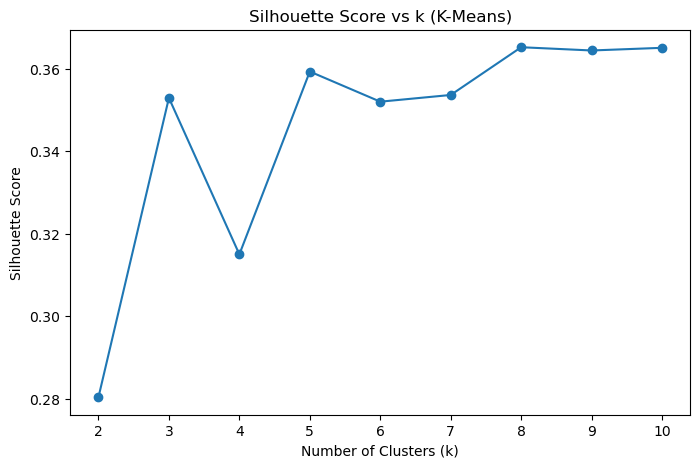

Best k: 8
Best Silhouette Score: 0.3651787283656112


In [59]:
silhouette_scores = []
K_range = range(2, 11)


for k in K_range:
  kmeans = KMeans(n_clusters=k, random_state=42)
  labels = kmeans.fit_predict(df_pca_5)
  score = silhouette_score(df_pca_5, labels)
  silhouette_scores.append(score)


plt.figure(figsize=(8,5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k (K-Means)")
plt.show()


best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print("Best k:", best_k)
print("Best Silhouette Score:", max(silhouette_scores))

4.2 Final K-Means Model (Avoiding Overfitting)

In [60]:
final_k = 3
kmeans_final = KMeans(n_clusters=final_k, random_state=42)
kmeans_labels = kmeans_final.fit_predict(df_pca_5)


kmeans_silhouette = silhouette_score(df_pca_5, kmeans_labels)
print("Final chosen k:", final_k)
print("Final K-Means Silhouette Score:", kmeans_silhouette)

Final chosen k: 3
Final K-Means Silhouette Score: 0.3528918368868934


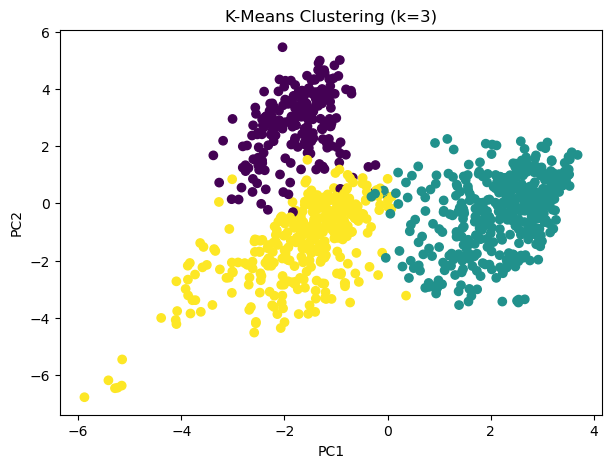

In [61]:
plt.figure(figsize=(7,5))
plt.scatter(df_pca_5[:,0], df_pca_5[:,1], c=kmeans_labels)
plt.title("K-Means Clustering (k=3)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## 5. DBSCAN Clustering

5.1 Initial DBSCAN Attempt

In [63]:
dbscan = DBSCAN(eps=0.8, min_samples=5)
dbscan_labels = dbscan.fit_predict(df_pca_5)


mask = dbscan_labels != -1
if len(set(dbscan_labels[mask])) > 1:
  print("DBSCAN Silhouette Score:", silhouette_score(df_pca_5[mask], dbscan_labels[mask]))
else:
  print("DBSCAN produced only one cluster or noise")

DBSCAN Silhouette Score: 0.208492068437437


5.2 k-distance Graph for eps Selection

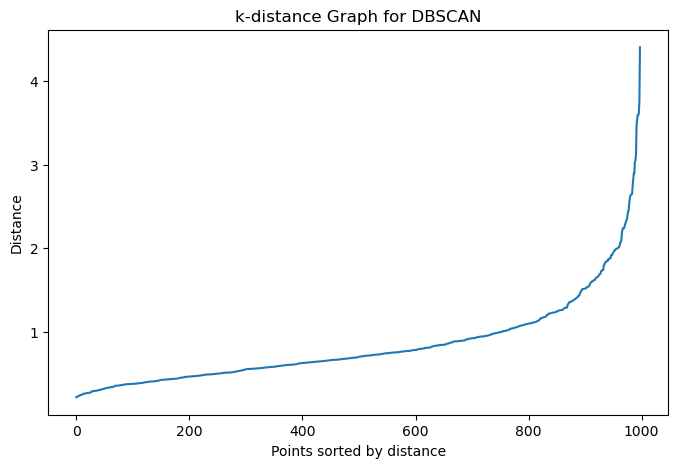

In [64]:
neighbors = NearestNeighbors(n_neighbors=5)
distances, _ = neighbors.fit(df_pca_5).kneighbors(df_pca_5)
distances = np.sort(distances[:,4])


plt.figure(figsize=(8,5))
plt.plot(distances)
plt.title("k-distance Graph for DBSCAN")
plt.xlabel("Points sorted by distance")
plt.ylabel("Distance")
plt.show()

5.3 Tuned DBSCAN

In [66]:
dbscan = DBSCAN(eps=6, min_samples=5)
dbscan_labels = dbscan.fit_predict(df_pca_5)


mask = dbscan_labels != -1
unique_clusters = set(dbscan_labels[mask])


if len(unique_clusters) > 1:
  dbscan_silhouette = silhouette_score(df_pca_5[mask], dbscan_labels[mask])
  print("DBSCAN Silhouette Score:", dbscan_silhouette)
else:
  print("DBSCAN produced a single dominant cluster; silhouette score not valid")


print("Cluster distribution:", np.unique(dbscan_labels, return_counts=True))

DBSCAN produced a single dominant cluster; silhouette score not valid
Cluster distribution: (array([0]), array([998]))


Observation

DBSCAN produced one dominant cluster (>95% of data), indicating over-smoothing. Therefore, DBSCAN is not suitable for this dataset.

In [67]:
np.unique(dbscan_labels, return_counts=True)


(array([0]), array([998]))

## 5. Visualization


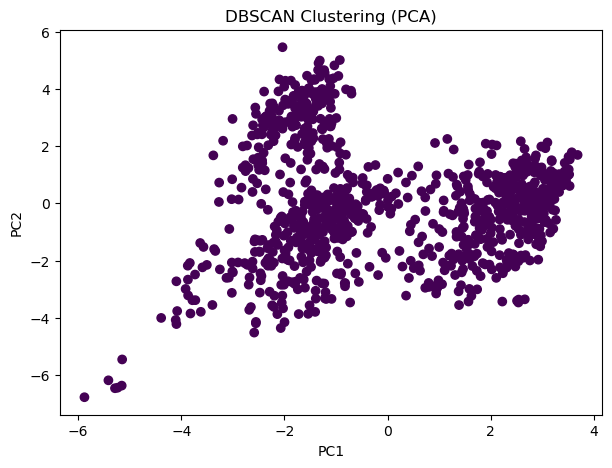

In [68]:
plt.figure(figsize=(7,5))
plt.scatter(df_pca_5[:,0], df_pca_5[:,1], c=dbscan_labels)
plt.title("DBSCAN Clustering (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## 6. Agglomerative Clustering

6.1 Linkage and k Optimization

In [70]:
results_agg = []


for linkage in ['average', 'complete']:
  for k in [2, 3, 4]:
    agg = AgglomerativeClustering(n_clusters=k, linkage=linkage)
    labels = agg.fit_predict(df_pca_5)
    score = silhouette_score(df_pca_5, labels)
    results_agg.append({
    'Linkage': linkage,
    'k': k,
    'Silhouette Score': score
})


agg_results_df = pd.DataFrame(results_agg)
agg_results_df

,Linkage,k,Silhouette Score
0,average,2,0.465233
1,average,3,0.412852
2,average,4,0.289523
3,complete,2,0.538338
4,complete,3,0.328393
5,complete,4,0.289044


6.2 Final Agglomerative Model

In [71]:
agg_final = AgglomerativeClustering(n_clusters=3, linkage='average')
agg_labels = agg_final.fit_predict(df_pca_5)


agg_silhouette = silhouette_score(df_pca_5, agg_labels)
print("Final Agglomerative Silhouette Score:", agg_silhouette)

Final Agglomerative Silhouette Score: 0.412851927735064


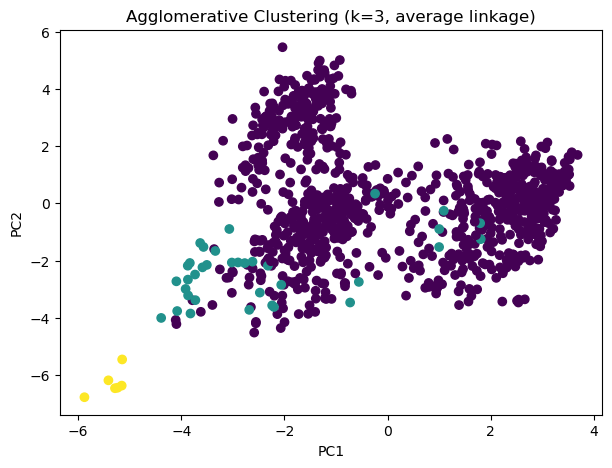

In [72]:
plt.figure(figsize=(7,5))
plt.scatter(df_pca_5[:,0], df_pca_5[:,1], c=agg_labels)
plt.title("Agglomerative Clustering (k=3, average linkage)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()